# 9. hafta ödev
Bu ödevde, COVID-19 BT görüntülerinde U-Net ile segmentasyon yapan tutorial'daki mantığı referans aldık. Ama ödevde model eğitimi yapmadık bunun yerine benzer mantıkla çalışan ve eğitim gerektirmeyen bölge büyütme (region growing) yöntemini tercih ettik.

Bu yöntem ile MR görüntülerindeki tümör bölgesini belirledik ve veri setinde bulunan gerçek maske (ground truth) görüntüleri ile elde edilen segmentasyon maskesini üst üste bindirerek Dice skorunu hesapladık.

Kodlar ve görüntüler aşağı detaylı şekilde verilmiştir.

**Bölge Büyütme (Region Growing):** Kullanıcı bir tohum noktası seçer. Algoritma seçilen noktadan başlar ve benzer piksel değerine sahip komşuları ekleyerek bölgeyi büyütür.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from skimage.segmentation import flood_fill

In [2]:
#MR görüntüsünü yükle
mr_image = files.upload()
mr_dosya = list(mr_image.keys())[0]

Saving 868.png to 868.png


Görüntü boyutu: (512, 512)


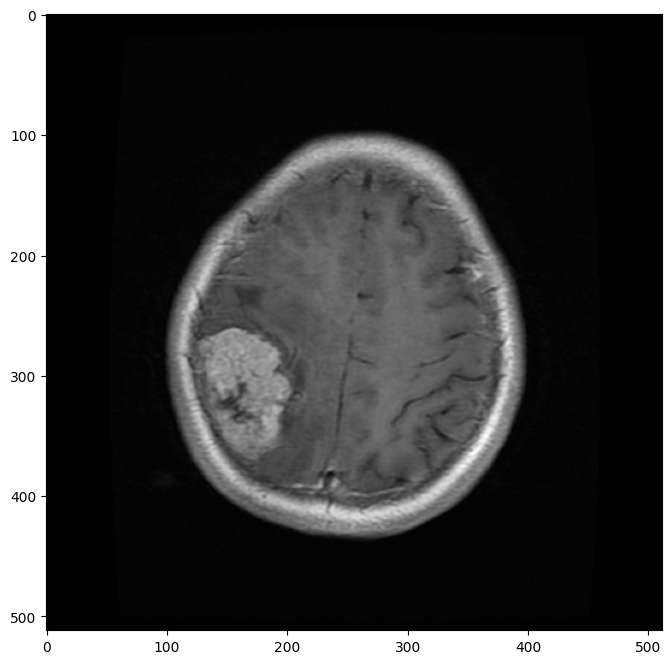

In [3]:
#görüntüyü oku/algıla
mr = cv2.imread(mr_dosya, cv2.IMREAD_GRAYSCALE)
print(f"Görüntü boyutu: {mr.shape}")

# görüntüyü göster (koordinat belirlemek için gerekli)
plt.figure(figsize=(8, 8))
plt.imshow(mr, cmap='gray')
plt.axis('on')  #koordinat
plt.grid(False)
plt.show()

In [4]:
# koordinatları girip tohum noktasını belirledik

x = int(input("Tümörün x koordinatı"))
y = int(input("Tümörün y koordinatı"))
tohum = (y, x)

print(f" Tohum noktası: ({x}, {y})")

Tümörün x koordinatı180
Tümörün y koordinatı300
 Tohum noktası: (180, 300)


In [5]:
#Bölge büyütme işlemi
tolerans = 25 #tohum noktasının piksel değerinin 25 üst ya da alt değeri alınır

segmentasyon = flood_fill(mr, tohum, 255, tolerance=tolerans)
segmentasyon = (segmentasyon == 255).astype(np.uint8) * 255

In [6]:
kernel = np.ones((3,3), np.uint8) #delikli sonuçlar elde edilirse bunu düzeltmek için önce close ile boşlıkları doldur sonra kenarları düzeltmek için open işlemi uygula
segmentasyon = cv2.morphologyEx(segmentasyon, cv2.MORPH_CLOSE, kernel)
segmentasyon = cv2.morphologyEx(segmentasyon, cv2.MORPH_OPEN, kernel)

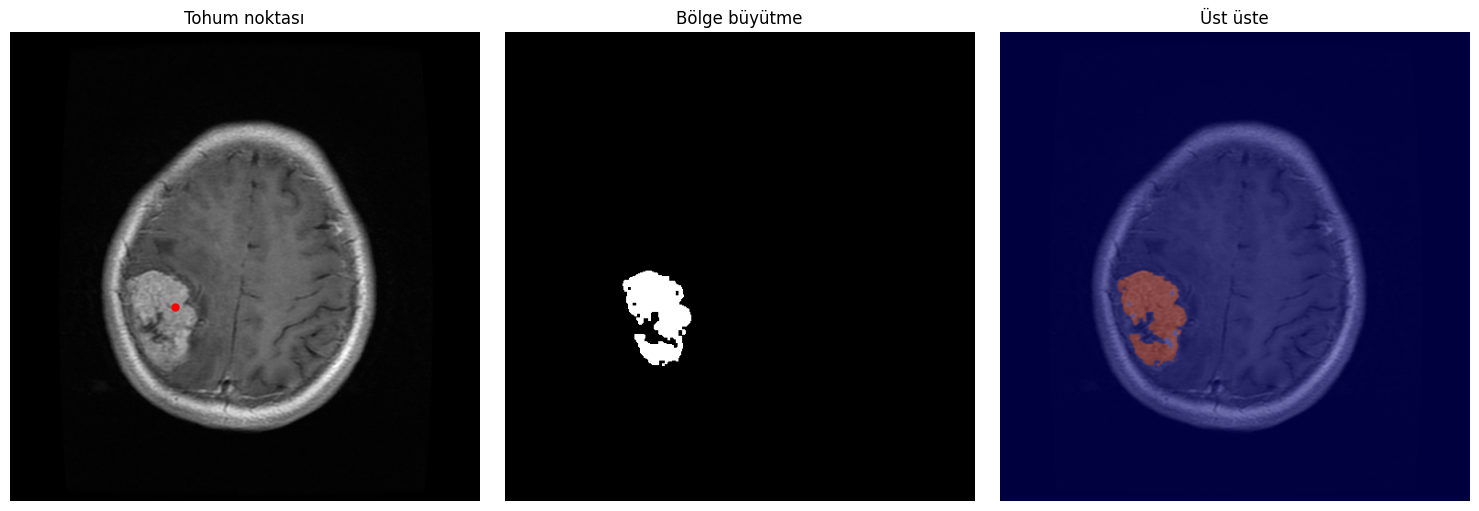

In [7]:
#  Sonuç
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(mr, cmap='gray')
axes[0].plot(x, y, 'ro', markersize=5)
axes[0].set_title('Tohum noktası')
axes[0].axis('off')

axes[1].imshow(segmentasyon, cmap='gray')
axes[1].set_title('Bölge büyütme')
axes[1].axis('off')

axes[2].imshow(mr, cmap='gray')
axes[2].imshow(segmentasyon, cmap='jet', alpha=0.5)
axes[2].set_title('Üst üste')
axes[2].axis('off')

plt.tight_layout()
plt.show()


Üstteki işlemde verilen koordinatı tohum olarak belirledik ve bölge büyütme ile tümörün tespitini yaptık. Daha sonra orijinal görüntü ile üst üste bindirdik (piksel bazında olmasa bile tümörün ne kadar örtüştüğünü görmek için)

Saving 868_mask.png to 868_mask.png
 Dice 0.8355


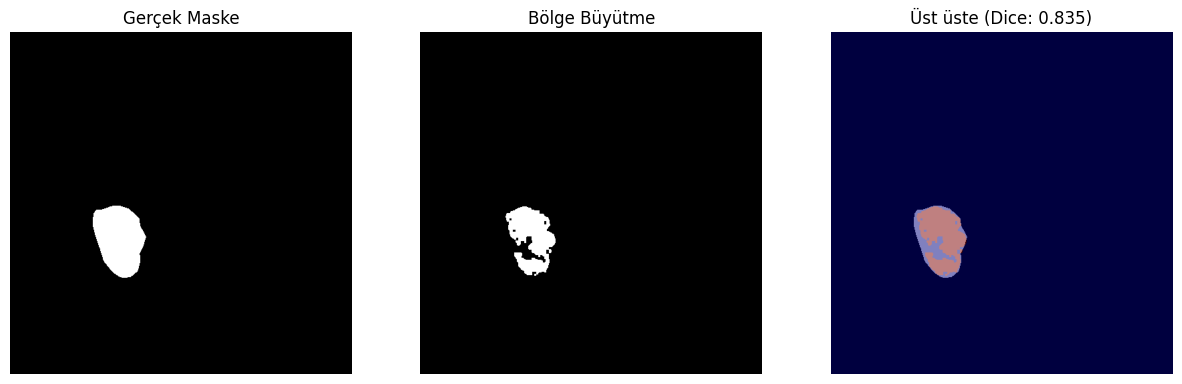

In [8]:
maske_img = files.upload()
maske_dosya = list(maske_img.keys())[0]
maske = cv2.imread(maske_dosya, cv2.IMREAD_GRAYSCALE)

maske_binary = (maske > 128).astype(np.uint8) # maskeyi ikilik görüntü yapar
seg_binary = (segmentasyon > 128).astype(np.uint8) # segmente edilmiş görüntüyü ikilik görüntü yapar

intersection = np.sum(maske_binary * seg_binary)
dice = (2. * intersection) / (np.sum(maske_binary) + np.sum(seg_binary) + 1e-6)

print(f" Dice {dice:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(maske, cmap='gray')
axes[0].set_title('Gerçek Maske')
axes[0].axis('off')
axes[1].imshow(segmentasyon, cmap='gray')
axes[1].set_title('Bölge Büyütme')
axes[1].axis('off')
axes[2].imshow(maske, cmap='gray')
axes[2].imshow(segmentasyon, cmap='jet', alpha=0.5)
axes[2].set_title(f'Üst üste (Dice: {dice:.3f})')
axes[2].axis('off')
plt.show()

Dice değerini 0.8355 olarak hesapladık. Başarılı segmentasyonlar için bu değerin genellikle 0.80 üzerinde olması tercih edilmektedir. Elde ettiğimiz 0.8355 değeri bu kriteri sağladığı için sonucumuzu başarılı ve kabul edilebilir olduğunu düşünüyoruz.

Bu işlemi birkaç görüntü üzerinde uyguladık

In [9]:
#MR görüntüsünü yükle
mr_image = files.upload()
mr_dosya = list(mr_image.keys())[0]

Saving 611.png to 611.png


Görüntü boyutu: (512, 512)


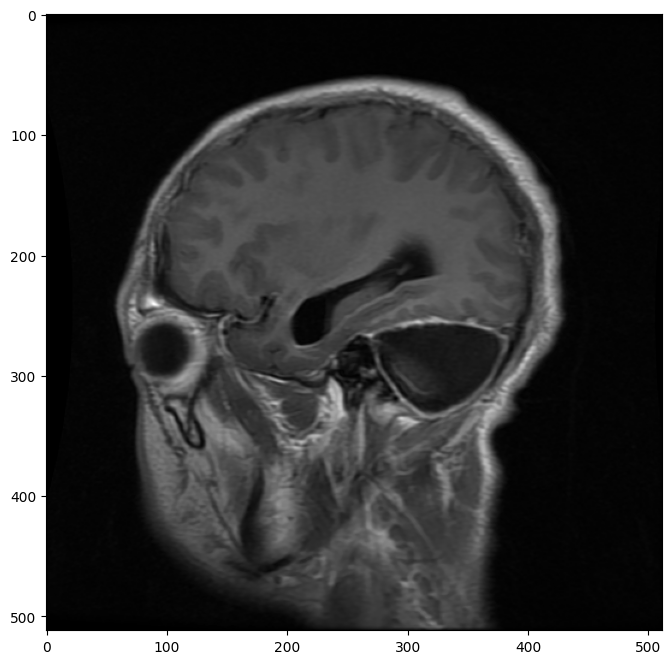

In [10]:
#görüntüyü oku/algıla
mr = cv2.imread(mr_dosya, cv2.IMREAD_GRAYSCALE)
print(f"Görüntü boyutu: {mr.shape}")

# görüntüyü göster (koordinat belirlemek için gerekli)
plt.figure(figsize=(8, 8))
plt.imshow(mr, cmap='gray')
plt.axis('on')  #koordinat
plt.grid(False)
plt.show()

In [11]:
# koordinatları girip tohum noktasını belirledik

x = int(input("Tümörün x koordinatı"))
y = int(input("Tümörün y koordinatı"))
tohum = (y, x)

print(f" Tohum noktası: ({x}, {y})")


Tümörün x koordinatı350
Tümörün y koordinatı280
 Tohum noktası: (350, 280)


In [12]:
#Bölge büyütme işlemi
tolerans = 25 #tohum noktasının piksel değerinin 25 üst ya da alt değeri alınır

segmentasyon = flood_fill(mr, tohum, 255, tolerance=tolerans)
segmentasyon = (segmentasyon == 255).astype(np.uint8) * 255

In [13]:
kernel = np.ones((3,3), np.uint8)
segmentasyon = cv2.morphologyEx(segmentasyon, cv2.MORPH_CLOSE, kernel)
segmentasyon = cv2.morphologyEx(segmentasyon, cv2.MORPH_OPEN, kernel)

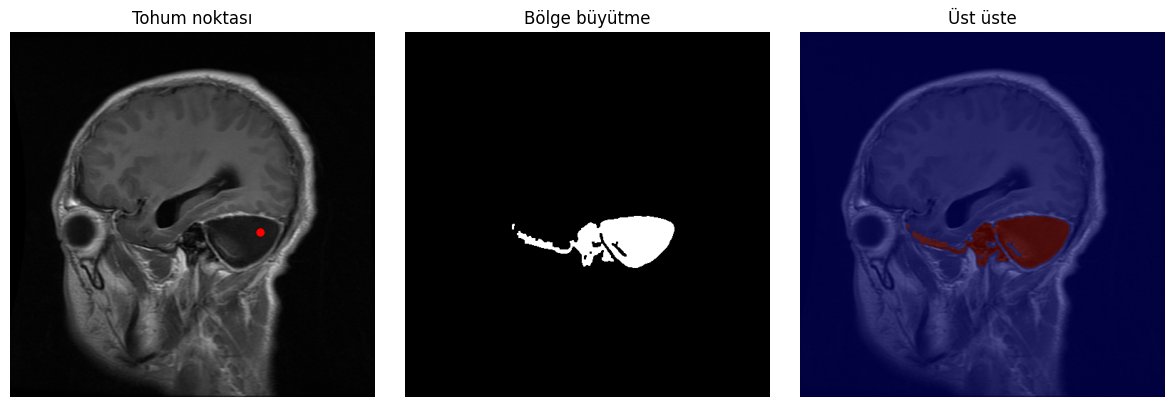

In [14]:
#  Sonuç
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(mr, cmap='gray')
axes[0].plot(x, y, 'ro', markersize=5)
axes[0].set_title('Tohum noktası')
axes[0].axis('off')

axes[1].imshow(segmentasyon, cmap='gray')
axes[1].set_title('Bölge büyütme')
axes[1].axis('off')

axes[2].imshow(mr, cmap='gray')
axes[2].imshow(segmentasyon, cmap='jet', alpha=0.5)
axes[2].set_title('Üst üste')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Saving 611_mask.png to 611_mask.png
 Dice 0.7828


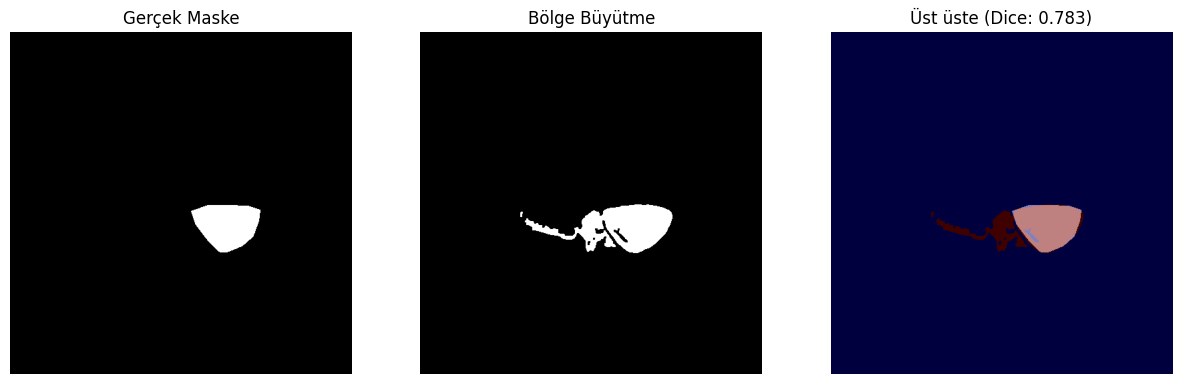

In [15]:
maske_img = files.upload()
maske_dosya = list(maske_img.keys())[0]
maske = cv2.imread(maske_dosya, cv2.IMREAD_GRAYSCALE)

maske_binary = (maske > 128).astype(np.uint8) # maskeyi ikilik görüntü yapar
seg_binary = (segmentasyon > 128).astype(np.uint8) # segmente edilmiş görüntüyü ikilik görüntü yapar

intersection = np.sum(maske_binary * seg_binary)
dice = (2. * intersection) / (np.sum(maske_binary) + np.sum(seg_binary) + 1e-6)

print(f" Dice {dice:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(maske, cmap='gray')
axes[0].set_title('Gerçek Maske')
axes[0].axis('off')
axes[1].imshow(segmentasyon, cmap='gray')
axes[1].set_title('Bölge Büyütme')
axes[1].axis('off')
axes[2].imshow(maske, cmap='gray')
axes[2].imshow(segmentasyon, cmap='jet', alpha=0.5)
axes[2].set_title(f'Üst üste (Dice: {dice:.3f})')
axes[2].axis('off')
plt.show()

Saving 972.png to 972.png
Görüntü boyutu: (512, 512)


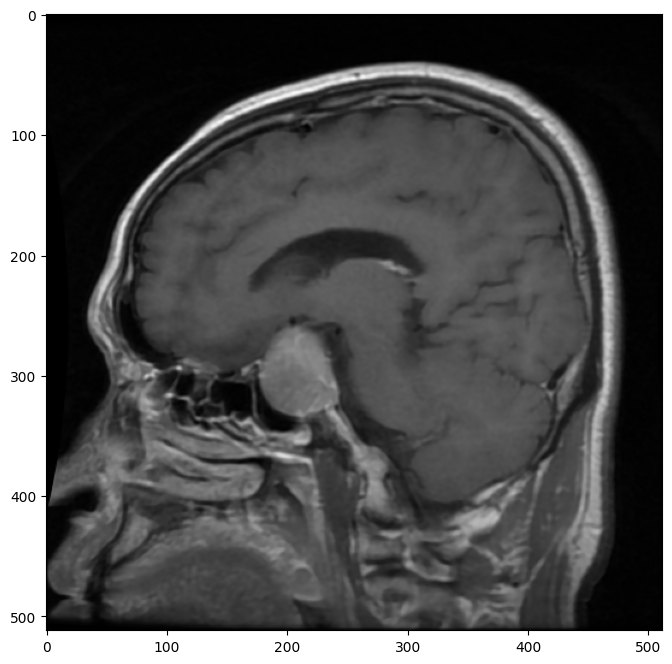

In [16]:
#MR görüntüsünü yükle
mr_image = files.upload()
mr_dosya = list(mr_image.keys())[0]

mr = cv2.imread(mr_dosya, cv2.IMREAD_GRAYSCALE)
print(f"Görüntü boyutu: {mr.shape}")

# görüntüyü göster (koordinat belirlemek için gerekli)
plt.figure(figsize=(8, 8))
plt.imshow(mr, cmap='gray')
plt.axis('on')  #koordinat
plt.grid(False)
plt.show()

In [17]:
x = int(input("Tümörün x koordinatı"))
y = int(input("Tümörün y koordinatı"))
tohum = (y, x)

print(f" Tohum noktası: ({x}, {y})")

Tümörün x koordinatı200
Tümörün y koordinatı300
 Tohum noktası: (200, 300)


In [18]:
#Bölge büyütme işlemi
tolerans = 25 #tohum noktasının piksel değerinin 25 üst ya da alt değeri alınır

segmentasyon = flood_fill(mr, tohum, 255, tolerance=tolerans)
segmentasyon = (segmentasyon == 255).astype(np.uint8) * 255

kernel = np.ones((3,3), np.uint8)
segmentasyon = cv2.morphologyEx(segmentasyon, cv2.MORPH_CLOSE, kernel)
segmentasyon = cv2.morphologyEx(segmentasyon, cv2.MORPH_OPEN, kernel)

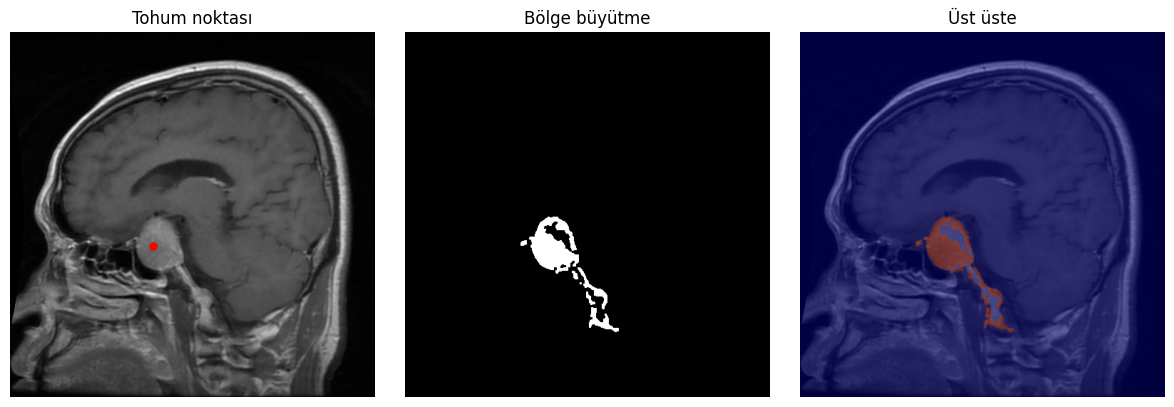

In [19]:
#  Sonuç
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(mr, cmap='gray')
axes[0].plot(x, y, 'ro', markersize=5)
axes[0].set_title('Tohum noktası')
axes[0].axis('off')

axes[1].imshow(segmentasyon, cmap='gray')
axes[1].set_title('Bölge büyütme')
axes[1].axis('off')

axes[2].imshow(mr, cmap='gray')
axes[2].imshow(segmentasyon, cmap='jet', alpha=0.5)
axes[2].set_title('Üst üste')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Saving 972_mask.png to 972_mask.png
 Dice 0.7165


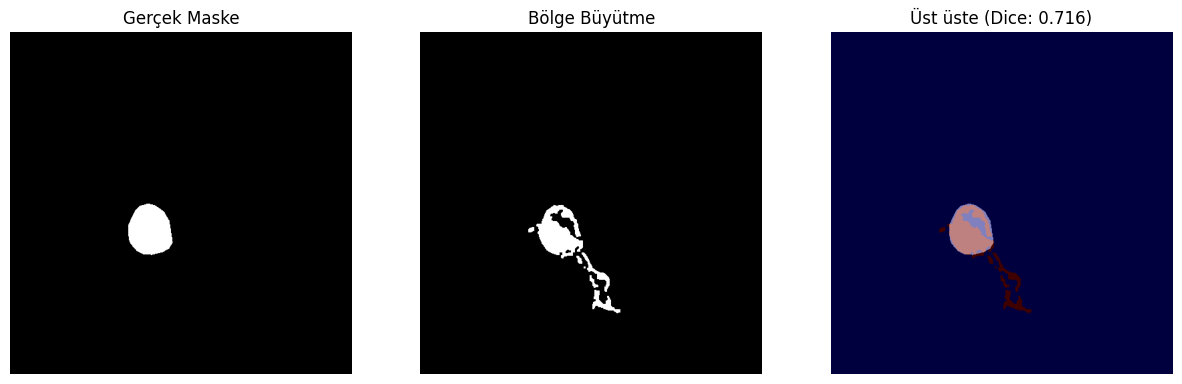

In [20]:
maske_img = files.upload()
maske_dosya = list(maske_img.keys())[0]
maske = cv2.imread(maske_dosya, cv2.IMREAD_GRAYSCALE)

maske_binary = (maske > 128).astype(np.uint8) # maskeyi ikilik görüntü yapar
seg_binary = (segmentasyon > 128).astype(np.uint8) # segmente edilmiş görüntüyü ikilik görüntü yapar

intersection = np.sum(maske_binary * seg_binary)
dice = (2. * intersection) / (np.sum(maske_binary) + np.sum(seg_binary) + 1e-6)

print(f" Dice {dice:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(maske, cmap='gray')
axes[0].set_title('Gerçek Maske')
axes[0].axis('off')
axes[1].imshow(segmentasyon, cmap='gray')
axes[1].set_title('Bölge Büyütme')
axes[1].axis('off')
axes[2].imshow(maske, cmap='gray')
axes[2].imshow(segmentasyon, cmap='jet', alpha=0.5)
axes[2].set_title(f'Üst üste (Dice: {dice:.3f})')
axes[2].axis('off')
plt.show()

Bölge büyütme algoritmasında en önemli parametrelerden biri tolerans değeridir. Bu parametrenin segmentasyon başarısına etkisini göstermek amacıyla aynı görüntü üzerinde iki farklı tolerans değeri sonucunu inceledik.

**TOLERANS DEĞERİ: 50**



Saving 931.png to 931.png
Görüntü boyutu: (512, 512)


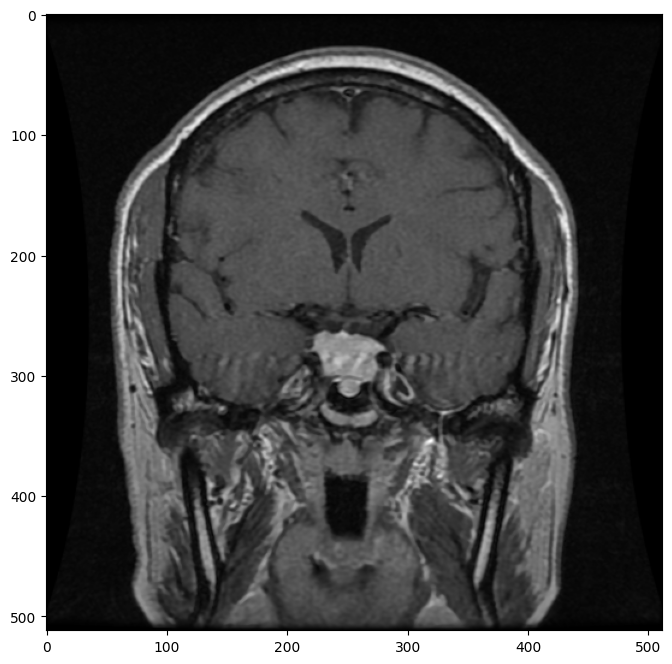

In [3]:
mr_image = files.upload()
mr_dosya = list(mr_image.keys())[0]

mr = cv2.imread(mr_dosya, cv2.IMREAD_GRAYSCALE)
print(f"Görüntü boyutu: {mr.shape}")
plt.figure(figsize=(8, 8))
plt.imshow(mr, cmap='gray')
plt.axis('on')  #koordinat
plt.grid(False)
plt.show()

In [4]:
x = int(input("Tümörün x koordinatı"))
y = int(input("Tümörün y koordinatı"))
tohum = (y, x)

print(f" Tohum noktası: ({x}, {y})")


tolerans = 50 #!!TOLERANS DEĞERİ

segmentasyon = flood_fill(mr, tohum, 255, tolerance=tolerans)
segmentasyon = (segmentasyon == 255).astype(np.uint8) * 255

kernel = np.ones((3,3), np.uint8)
segmentasyon = cv2.morphologyEx(segmentasyon, cv2.MORPH_CLOSE, kernel)
segmentasyon = cv2.morphologyEx(segmentasyon, cv2.MORPH_OPEN, kernel)

Tümörün x koordinatı250
Tümörün y koordinatı285
 Tohum noktası: (250, 285)


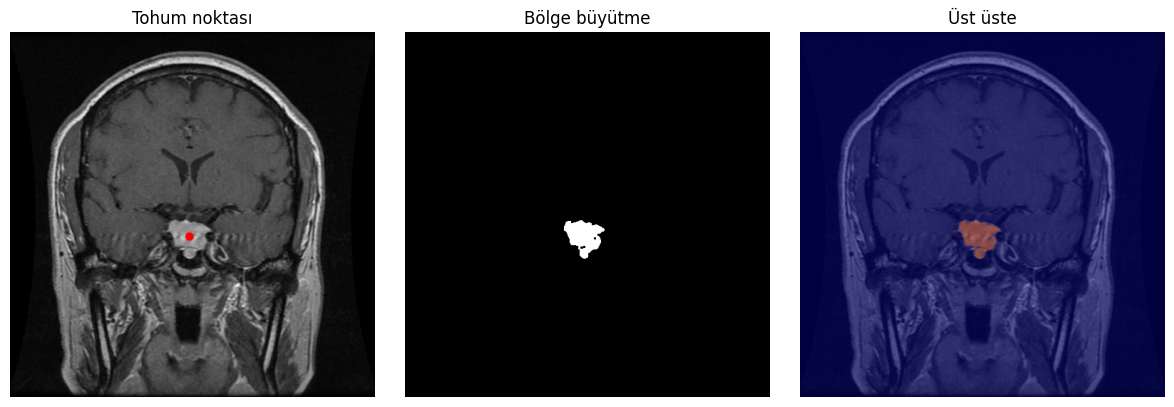

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(mr, cmap='gray')
axes[0].plot(x, y, 'ro', markersize=5)
axes[0].set_title('Tohum noktası')
axes[0].axis('off')

axes[1].imshow(segmentasyon, cmap='gray')
axes[1].set_title('Bölge büyütme')
axes[1].axis('off')

axes[2].imshow(mr, cmap='gray')
axes[2].imshow(segmentasyon, cmap='jet', alpha=0.5)
axes[2].set_title('Üst üste')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Saving 931_mask.png to 931_mask.png
 Dice 0.9009


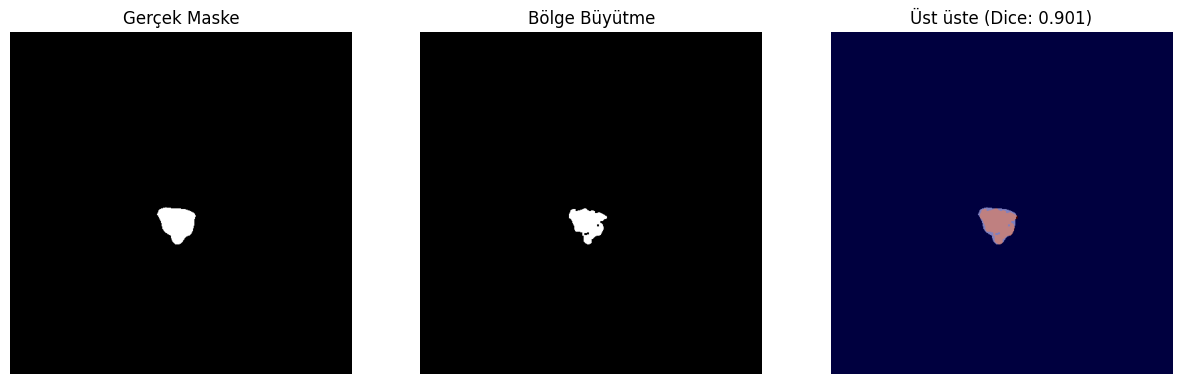

In [6]:
maske_img = files.upload()
maske_dosya = list(maske_img.keys())[0]
maske = cv2.imread(maske_dosya, cv2.IMREAD_GRAYSCALE)

maske_binary = (maske > 128).astype(np.uint8) # maskeyi ikilik görüntü yapar
seg_binary = (segmentasyon > 128).astype(np.uint8) # segmente edilmiş görüntüyü ikilik görüntü yapar

intersection = np.sum(maske_binary * seg_binary)
dice = (2. * intersection) / (np.sum(maske_binary) + np.sum(seg_binary) + 1e-6)

print(f" Dice {dice:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(maske, cmap='gray')
axes[0].set_title('Gerçek Maske')
axes[0].axis('off')
axes[1].imshow(segmentasyon, cmap='gray')
axes[1].set_title('Bölge Büyütme')
axes[1].axis('off')
axes[2].imshow(maske, cmap='gray')
axes[2].imshow(segmentasyon, cmap='jet', alpha=0.5)
axes[2].set_title(f'Üst üste (Dice: {dice:.3f})')
axes[2].axis('off')
plt.show()

**TOLERANS DEĞERİ: 25**

Saving 931.png to 931 (1).png
Görüntü boyutu: (512, 512)


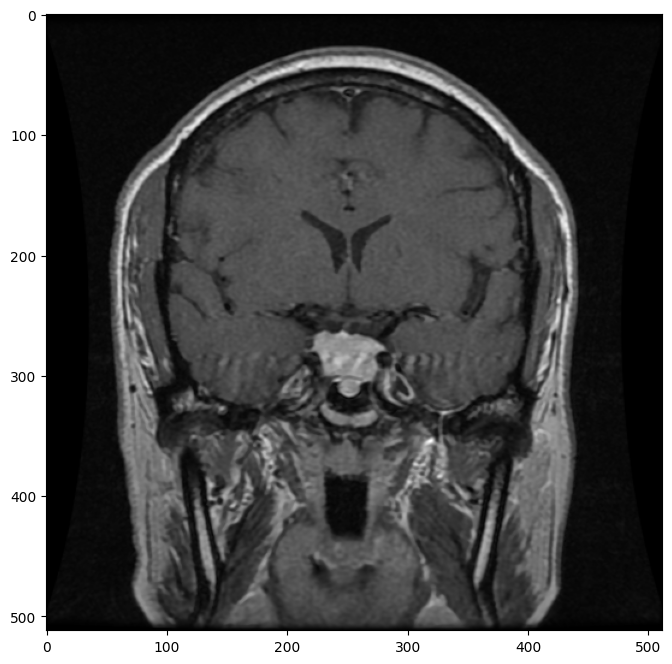

Tümörün x koordinatı250
Tümörün y koordinatı285
 Tohum noktası: (250, 285)


In [7]:
mr_image = files.upload()
mr_dosya = list(mr_image.keys())[0]

mr = cv2.imread(mr_dosya, cv2.IMREAD_GRAYSCALE)
print(f"Görüntü boyutu: {mr.shape}")

# görüntüyü göster (koordinat belirlemek için gerekli)
plt.figure(figsize=(8, 8))
plt.imshow(mr, cmap='gray')
plt.axis('on')  #koordinat
plt.grid(False)
plt.show()

x = int(input("Tümörün x koordinatı"))
y = int(input("Tümörün y koordinatı"))
tohum = (y, x)

print(f" Tohum noktası: ({x}, {y})")

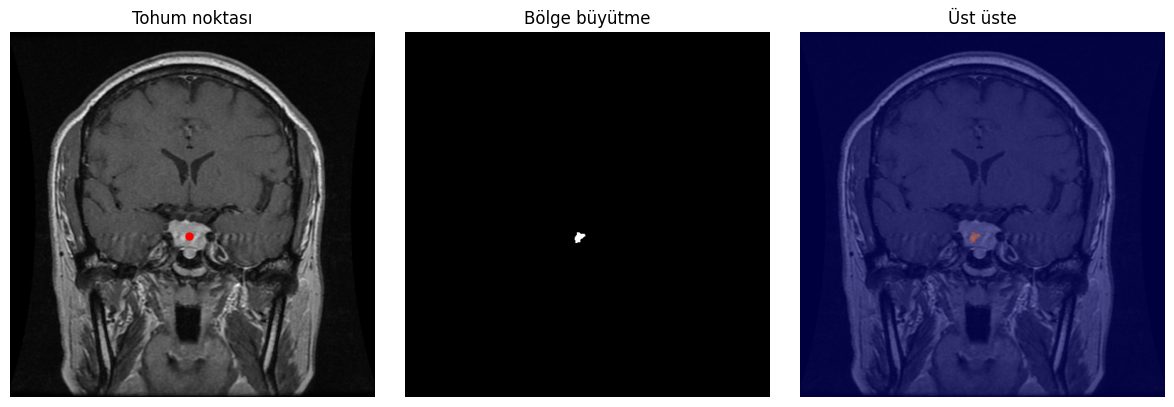

In [8]:
tolerans = 25 #TOLERANS DEĞERİNİ DEĞİŞTİRDİK

segmentasyon = flood_fill(mr, tohum, 255, tolerance=tolerans)
segmentasyon = (segmentasyon == 255).astype(np.uint8) * 255

kernel = np.ones((3,3), np.uint8)
segmentasyon = cv2.morphologyEx(segmentasyon, cv2.MORPH_CLOSE, kernel)
segmentasyon = cv2.morphologyEx(segmentasyon, cv2.MORPH_OPEN, kernel)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(mr, cmap='gray')
axes[0].plot(x, y, 'ro', markersize=5)
axes[0].set_title('Tohum noktası')
axes[0].axis('off')

axes[1].imshow(segmentasyon, cmap='gray')
axes[1].set_title('Bölge büyütme')
axes[1].axis('off')

axes[2].imshow(mr, cmap='gray')
axes[2].imshow(segmentasyon, cmap='jet', alpha=0.5)
axes[2].set_title('Üst üste')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Saving 931_mask.png to 931_mask (1).png
 Dice 0.1171


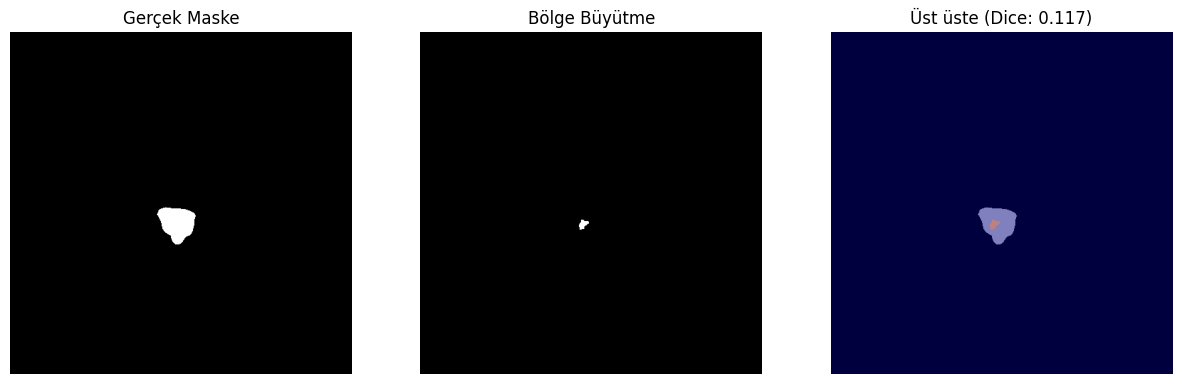

In [9]:
maske_img = files.upload()
maske_dosya = list(maske_img.keys())[0]
maske = cv2.imread(maske_dosya, cv2.IMREAD_GRAYSCALE)

maske_binary = (maske > 128).astype(np.uint8) # maskeyi ikilik görüntü yapar
seg_binary = (segmentasyon > 128).astype(np.uint8) # segmente edilmiş görüntüyü ikilik görüntü yapar

intersection = np.sum(maske_binary * seg_binary)
dice = (2. * intersection) / (np.sum(maske_binary) + np.sum(seg_binary) + 1e-6)

print(f" Dice {dice:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(maske, cmap='gray')
axes[0].set_title('Gerçek Maske')
axes[0].axis('off')
axes[1].imshow(segmentasyon, cmap='gray')
axes[1].set_title('Bölge Büyütme')
axes[1].axis('off')
axes[2].imshow(maske, cmap='gray')
axes[2].imshow(segmentasyon, cmap='jet', alpha=0.5)
axes[2].set_title(f'Üst üste (Dice: {dice:.3f})')
axes[2].axis('off')
plt.show()

Tolerans değerini 50 olarak belirlediğimizde Dice skorunu 0.9009 olarak elde ettik. Bu değer segmentasyonun oldukça başarılı olduğunu gösteriyor.

Ancak aynı görüntü üzerinde tolerans değerini 25 olarak aldığımızda Dice skoru 0.1171'e düşmüştür. Bu kadar düşük bir değer segmentasyonun başarısız olduğunu gösterir.

Yani segmentasyon başarısı için tolerans değeri oldukça önemlidir. Tolerans değerinin çok düşük seçilmesi tümörünün algılanmamasını yol açabilir. Benzer şekilde tolerans değerinin çok yüksek seçilmesi ise tümör dışındaki dokuların da yanlışlıkla tümör olarak algılanmasına neden olabilir.